In [ ]:
随机模拟中有一个重要的问题就是给定一个概率分布p(x)，如何在计算机中生成它的样本。一般而言均匀分布 Uniform(0,1)的样本是相对容易生成的。 通过线性同余发生器可以生成伪随机数，我们用确定性算法生成[0,1]之间的伪随机数序列后，这些序列的各种统计指标和均匀分布 Uniform(0,1) 的理论计算结果非常接近。这样的伪随机序列就有比较好的统计性质，可以被当成真实的随机数使用

### 蒙特卡洛积分
+ 如果需要求f(x)的积分，但是f(x)的格式复杂不好求，则可以用数值法来求解近似结果
+ 常用的是蒙特卡洛方法 $\int_{a}^{b} \frac{f(x)}{q(x)} q(x) d x$， q(x)为可以看作x在区间内的分布， $ \frac{f(x)}{q(x)} $ 看作一个函数，然后在q(x)下抽取n个样本，当n足够大时，可以用$\frac{f(x)}{q(x)}$ 多次采样的均值来表示f(x)的积分

In [ ]:
### Gibbs
+ https://zh.wikipedia.org/wiki/%E5%90%89%E5%B8%83%E6%96%AF%E9%87%87%E6%A0%B7
+ 吉布斯采样适用于条件分布比边缘分布更容易采样的多变量分布

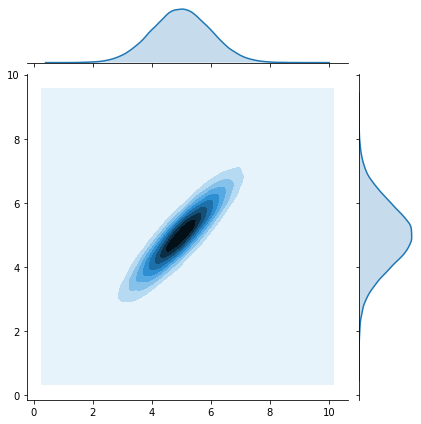

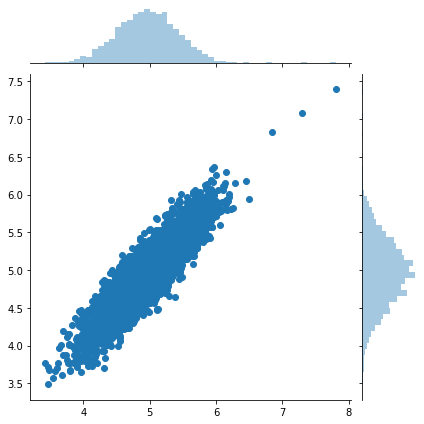

In [2]:
"""
Created on Fri Mar 30 10:49:33 2018
E-mail = Eric2014_Lv@sjtu.edu.cn 
@author: DidiLv
"""

import numpy as np
import seaborn as sns

def p_x_given_y(y, mus, sigmas):
    # 二元高斯分布计算边缘分布
    # 
    mu = mus[0] + sigmas[1, 0] / sigmas[0, 0] * (y - mus[1])
    sigma = sigmas[0, 0] - sigmas[1, 0] / sigmas[1, 1] * sigmas[1, 0]
    return np.random.normal(mu, sigma) # Gaussian 分布

def p_y_given_x(x, mus, sigmas):
    mu = mus[1] + sigmas[0, 1] / sigmas[1, 1] * (x - mus[0])
    sigma = sigmas[1, 1] - sigmas[0, 1] / sigmas[0, 0] * sigmas[0, 1]
    return np.random.normal(mu, sigma)

def gibbs_sampling(mus, sigmas, iter=int(5e3)):
    samples = np.zeros((iter, 2))
    y = np.random.rand() * 10

    for i in range(iter):
        x = p_x_given_y(y, mus, sigmas)
        y = p_y_given_x(x, mus, sigmas)
        samples[i, :] = [x, y]

    return samples

if __name__ == '__main__':
    mus = np.array([5, 5])
    sigmas = np.array([[1, .9], [.9, 1]])

    # plot the ground truth
    # 多元正太分布
    x,y = np.random.multivariate_normal(mus, sigmas, int(1e5)).T
    sns.jointplot(x,y,kind="kde")

    # plot the Gibbs sampling results
    samples = gibbs_sampling(mus, sigmas)
    sns.jointplot(samples[:, 0], samples[:, 1])

In [ ]:
### References
+ https://zhuanlan.zhihu.com/p/109978580
+ https://github.com/zhuanxuhit/math-foundation/blob/master/mcmc/gibbs-sampling.ipynb
+ Introduction to MCMC for Machine Learning
+ https://wiseodd.github.io/techblog/2015/10/09/gibbs-sampling/

In [ ]:
Gibbs sampling 是 Metropolis-Hastings 的一个特殊情况

In [ ]:
https://zhuanlan.zhihu.com/p/21275614 有一些观点未理解
